# Week 10 - Machine Learning: Computer Vision Lab Exercise
## Exercise 1: Install the required libraries and its dependences.

In [1]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable


In [2]:
!pip install numpy

Defaulting to user installation because normal site-packages is not writeable


In [3]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [4]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [5]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable


In [6]:
!pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/38.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.8 MB 660.6 kB/s eta 0:00:59
   ---------------------------------------- 0.2/38.8 MB 2.0 MB/s eta 0:00:20
   ---------------------------------------- 0.4/38.8 MB 3.4 MB/s eta 0:00:12
    --------------------------------------- 0.6/38.8 MB 4.3 MB/s eta 0:00:09
    --------------------------------------- 0.6/38.8 MB 3.3 MB/s eta 0:00:12
    --------------------------------------- 0.9/38.8 MB 3.4 MB/s eta 0:00:12
   - -------------------------------------- 1.0/38.8 MB 3.4 MB/s eta 0:00:12
   - -------------------------------------- 1.0/38.8 MB 3.4 MB/s eta 0:00:12
   - -------------------------------------- 1.2/38.8 MB 3.0 MB/s eta 0:00:13
   - -------------------------------------- 1.3/38.8 MB 2.9 MB/s eta 0:00:13
   - -------------------------------------- 1.3/38.8 MB 2.9 MB/s eta 0:00:13
   

## Exercise 2: Download an image and save it in the same directory as the Jupiter notebook to use in the next few examples. You can rename the image to Image_1 to make it easier to use in the script. Keep a note of the file format as you will be using it in the script.

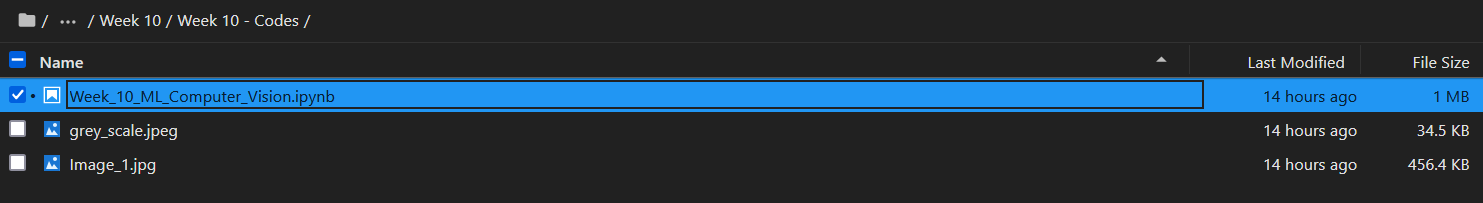

## Exercise 3: Initially we will start with open image file and showing it using cv2.

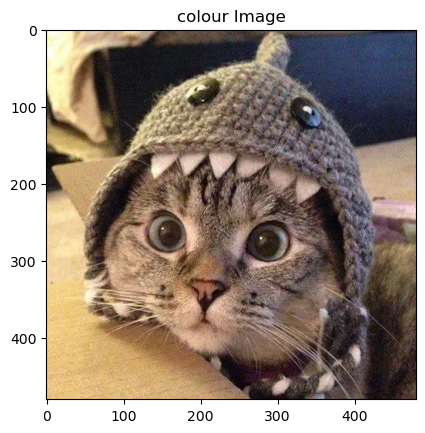

In [1]:
import cv2 
import numpy as np 
import matplotlib.pyplot as plt 

image_path = 'Image_1.jpg' 
image = cv2.imread(image_path) 
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) 
plt.imshow(image_rgb) 
plt.title('colour Image') 
plt.show()

## Exercise 4: Now we will open the image file in grey scale.

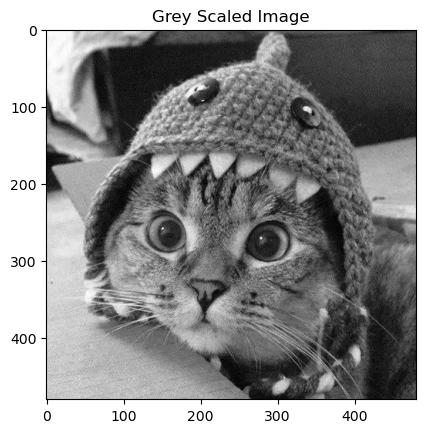

In [8]:
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE) 
plt.imshow(image, cmap='gray') 
plt.title('Grey Scaled Image') 
plt.show()

## Exercise 5: To save the image in grey scale we can use:

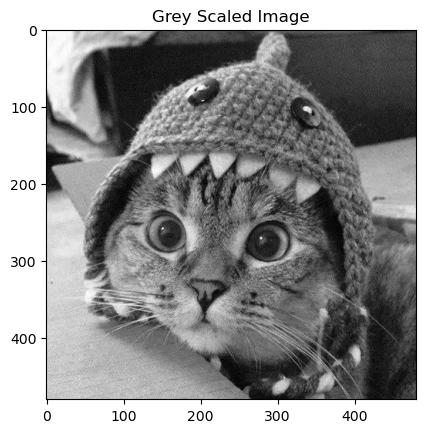

In [9]:
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE) 
plt.imshow(image, cmap='gray') 
plt.title('Grey Scaled Image') 
plt.savefig('grey_scale.jpeg') 
plt.show()

## Exercise 6: To get the image resolution we can use.

In [11]:
print(image.shape)

(480, 480)


## Exercise 7: To crop a part of the image we can use the same slicing method for python array as follows:

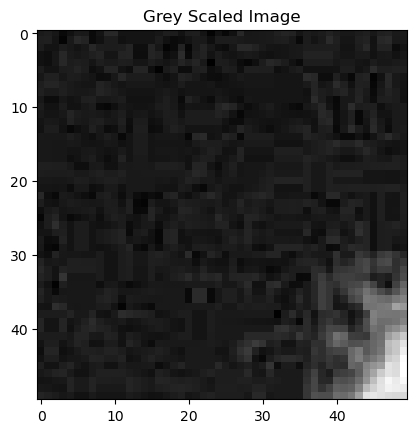

In [22]:
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE) 
image = image[50:100,100:150] 
plt.imshow(image, cmap='gray') 
plt.title('Grey Scaled Image') 
plt.show()

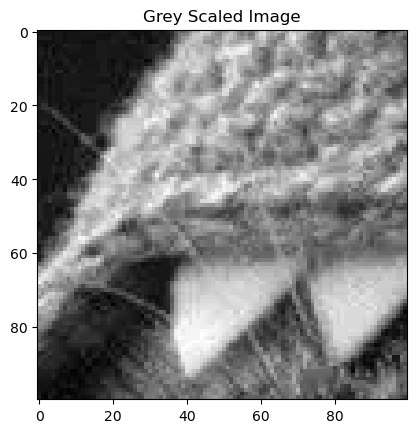

In [20]:
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE) 
image = image[100:200,100:200] 
plt.imshow(image, cmap='gray') 
plt.title('Grey Scaled Image') 
plt.show()

## Exercise 8: Plot a histogram for the grey scale image.

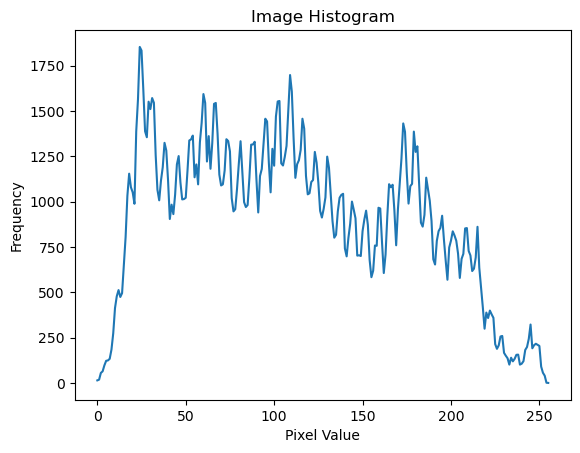

In [23]:
# Calculate histogram using OpenCV 
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE) 
hist = cv2.calcHist([image], [0], None, [256], [0, 256]) 
plt.plot(hist) 
plt.title('Image Histogram') 
plt.xlabel('Pixel Value') 
plt.ylabel('Frequency') 
plt.show()

## Exercise 9: To work on image using the commonly used libraires such as karas we can use the built in tools to do so

In [ ]:
import keras 
from tensorflow.keras.utils import load_img 

# load the image 
img = load_img(image_path) 

# find more about the image 
print(type(img)) 
print(img.format) 
print(img.mode) 
print(img.size) 

# show the image 
img.show()

<class 'PIL.PngImagePlugin.PngImageFile'>
PNG
RGB
(480, 480)


## Exercise 10: In the next part we will be developing an image classifier using karas. To do so we need to use a special type of neural networks called Convolutional Neural Networks (CNN).

- CNNs are a type of neural network that is particularly good at image recognition and computer vision tasks.
- They are able to accomplish this by identifying patterns in images.
- CNNs are made up of multiple layers, including convolutional layers, pooling layers, and fully-connected layers. Each layer performs a specific function to extract increasingly complex features from the image.
- Convolutional neural networks are a powerful tool that can be used for a variety of applications, including social media, healthcare, and retail.

## Exercise 11: Will start by importing the libraries.

In [2]:
import keras 
from tensorflow.keras.utils import load_img 
from keras.models import Sequential 
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense 
from keras.utils import to_categorical 
from keras.datasets import mnist

## Exercise 12: Load the dataset and split it intro train and test.

In [3]:
# Load the MNIST dataset 
(X_train, y_train), (X_test, y_test) = mnist.load_data() 

# Reshape the images and normalize pixel values to be between 0 and 1 
X_train = X_train.reshape(-1, 28, 28, 1).astype('float64') / 255.0 
X_test = X_test.reshape(-1, 28, 28, 1).astype('float64') / 255.0

A local file was found, but it seems to be incomplete or outdated because the auto file hash does not match the original value of 731c5ac602752760c8e48fbffcf8c3b850d9dc2a2aedcf2cc48468fc17b673d1 so we will re-download the data.
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 7s 1us/step


In [3]:
# Load the MNIST dataset 
(X_train, y_train), (X_test, y_test) = mnist.load_data() 

# Reshape the images and normalize pixel values to be between 0 and 1 
X_train = X_train.reshape(-1, 28, 28, 1).astype('float64') / 255.0 
X_test = X_test.reshape(-1, 28, 28, 1).astype('float64') / 255.0

## Exercise 13: Visualise an example of the images and their labels.

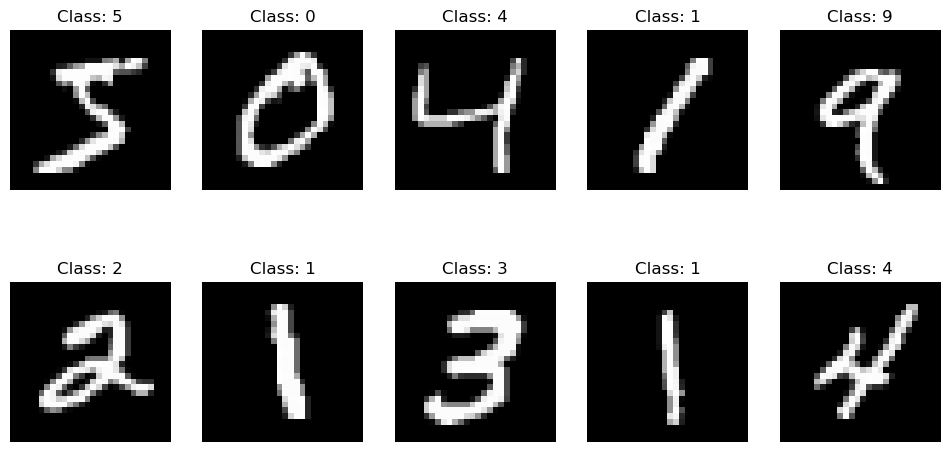

In [4]:
# Display images and corresponding class names 
num_rows, num_cols = 2, 5 # Display 2 rows and 5 columns of images 
plt.figure(figsize=(12, 6)) 

for i in range(num_rows * num_cols): 
    plt.subplot(num_rows, num_cols, i + 1) 
    plt.imshow(X_train[i], cmap='gray') 
    plt.title(f'Class: {y_train[i]}') 
    plt.axis('off') 
    
plt.show()

## Exercise 14: Encode the label names using:

In [5]:
# One-hot encode the labels 
y_train = to_categorical(y_train, 10) 
y_test = to_categorical(y_test, 10)

## Exercise 15

- Conv2D layers **extract features** from the image.
- MaxPooling2D layers **reduce the size** of the data and **summarize** the features.

In [6]:
# Build the CNN model 
model = Sequential() 
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1))) 
model.add(MaxPooling2D((2, 2))) 
model.add(Conv2D(64, (3, 3), activation='relu')) 
model.add(MaxPooling2D((2, 2))) 
model.add(Conv2D(64, (3, 3), activation='relu')) 
model.add(Flatten()) 
model.add(Dense(64, activation='relu')) 
model.add(Dense(10, activation='softmax')) 

# Compile the model 
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

C:\Users\Htut Myat Oo\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Exercise 16: Train the model, please note that training it will take few mins.

In [7]:
# Train the model 
model.fit(X_train, y_train, epochs=5, batch_size=64, validation_data=(X_test, y_test))

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 28s 27ms/step - accuracy: 0.8754 - loss: 0.4242 - val_accuracy: 0.9797 - val_loss: 0.0623
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 26s 28ms/step - accuracy: 0.9826 - loss: 0.0544 - val_accuracy: 0.9890 - val_loss: 0.0351
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 24ms/step - accuracy: 0.9879 - loss: 0.0369 - val_accuracy: 0.9909 - val_loss: 0.0283
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.9913 - loss: 0.0273 - val_accuracy: 0.9905 - val_loss: 0.0285
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 23s 25ms/step - accuracy: 0.9930 - loss: 0.0207 - val_accuracy: 0.9909 - val_loss: 0.0299


## Exercise 17: Finally evaluate its performance:

In [8]:
# Evaluate the model 
loss, accuracy = model.evaluate(X_test, y_test) 
print(f'Test Accuracy: {accuracy * 100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9879 - loss: 0.0381
Test Accuracy: 99.09%


## Exercise 18: To check an example of correctly classified and misclassified images, we can search for the labels of the predictions and compare it to the labels of the dataset.

In [9]:
# Predictions on the test set 
predictions = model.predict(X_test) 

# Find indices of correctly and incorrectly classified images 
correct_indices = np.where(np.argmax(predictions, axis=1) == np.argmax(y_test, axis=1))[0] 
incorrect_indices = np.where(np.argmax(predictions, axis=1) != np.argmax(y_test, axis=1))[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


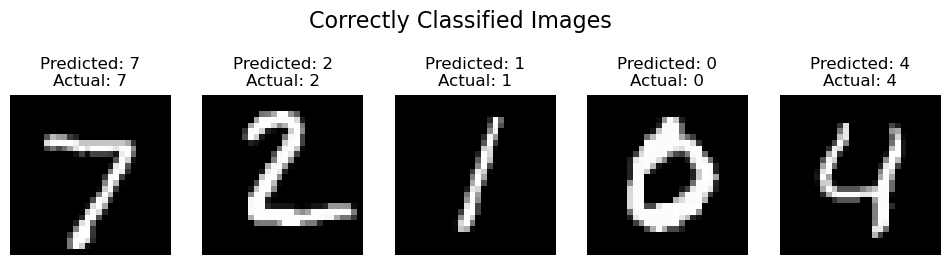

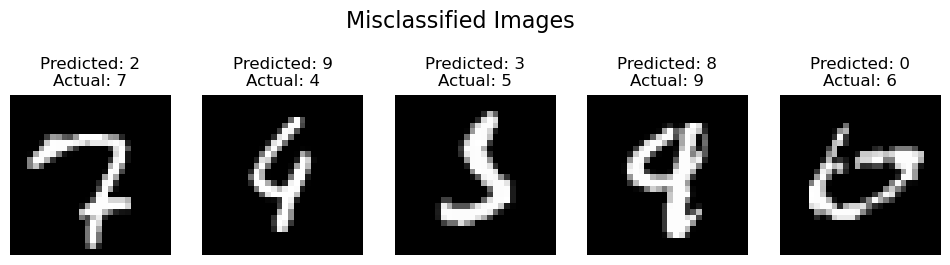

In [10]:
# Visualization

# Display examples of correctly classified images
plt.figure(figsize=(12, 6))
plt.suptitle('Correctly Classified Images', fontsize=16)

for i in range(5):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[correct_indices[i]].reshape(28, 28), cmap='gray')
    plt.title(f'Predicted: {np.argmax(predictions [correct_indices[i]])}\nActual: {np.argmax(y_test[correct_indices[i]])}') 
    plt.axis('off')

# Display examples of misclassified images
plt.figure(figsize=(12, 6))
plt.suptitle('Misclassified Images', fontsize=16)

for i in range(5):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[incorrect_indices[i]].reshape(28, 28), cmap='gray')
    plt.title(f'Predicted: {np.argmax(predictions[incorrect_indices[i]])}\nActual: {np.argmax(y_test[incorrect_indices[i]])}')
    plt.axis('off')

plt.show()

## Exercise 19: Answer the quiz available via canvas.

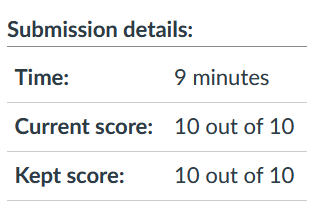

Yes, I've started working on the assessment since Week 6 by discussing it with my tutor via Microsoft Team.